K-Means Clustering

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [9]:
df = pd.read_csv("renewable_energy_dataset.csv")

print(df.head())

   Country  Year  Solar_Energy_GWh  Wind_Energy_GWh  Hydro_Energy_GWh  \
0    India  2024              1412              504              6874   
1  Germany  2024              4967             1012              5637   
2      USA  2024              2128             3736              2605   
3    China  2024              3962             3087              3076   
4   Brazil  2024              3440             3117              5745   

   Biomass_Energy_GWh  Renewable_Share_Percent  CO2_Emissions_Mt  \
0                 663                    37.14            134.19   
1                 964                    22.22             93.39   
2                1019                    61.25            730.39   
3                 418                    35.07            689.51   
4                 641                    76.50            659.46   

   GDP_Billion_USD  Population_Million  
0          2607.25             1075.26  
1          5854.89              874.92  
2           212.14           

In [10]:
print(df.tail())

print(df.shape)

print(df.columns)

df.info()

print(df.describe())

     Country  Year  Solar_Energy_GWh  Wind_Energy_GWh  Hydro_Energy_GWh  \
5     Canada  2024              3600              945              5322   
6  Australia  2024              1069              675              6217   
7      Japan  2024              3613             2577              4514   
8     France  2024              1084             1701              5175   
9     Norway  2024              2299             2956              1258   

   Biomass_Energy_GWh  Renewable_Share_Percent  CO2_Emissions_Mt  \
5                 700                    78.06            560.48   
6                 566                    74.11            886.85   
7                1401                    78.39            154.76   
8                 601                    31.44            347.72   
9                 569                    77.53            726.49   

   GDP_Billion_USD  Population_Million  
5         21549.59              839.27  
6         21390.18             1257.07  
7          8914.0

In [11]:
print(df.tail())

print(df.shape)

print(df.columns)

df.info()

print(df.describe())

     Country  Year  Solar_Energy_GWh  Wind_Energy_GWh  Hydro_Energy_GWh  \
5     Canada  2024              3600              945              5322   
6  Australia  2024              1069              675              6217   
7      Japan  2024              3613             2577              4514   
8     France  2024              1084             1701              5175   
9     Norway  2024              2299             2956              1258   

   Biomass_Energy_GWh  Renewable_Share_Percent  CO2_Emissions_Mt  \
5                 700                    78.06            560.48   
6                 566                    74.11            886.85   
7                1401                    78.39            154.76   
8                 601                    31.44            347.72   
9                 569                    77.53            726.49   

   GDP_Billion_USD  Population_Million  
5         21549.59              839.27  
6         21390.18             1257.07  
7          8914.0

In [12]:
# Country
# Name of the country.

# Year
# Year of observation.

# Solar Energy
# Electricity generated from solar energy.

# Wind Energy
# Electricity generated from wind.

# Hydro Energy
# Electricity generated from water.

# Biomass
# Energy generated from biomass.

# Total Renewable Energy
# Total renewable energy production.

# Population
# Total population.

# GDP
# Gross Domestic Product.

In [13]:
print(df.isnull().sum())

Country                    0
Year                       0
Solar_Energy_GWh           0
Wind_Energy_GWh            0
Hydro_Energy_GWh           0
Biomass_Energy_GWh         0
Renewable_Share_Percent    0
CO2_Emissions_Mt           0
GDP_Billion_USD            0
Population_Million         0
dtype: int64


In [14]:
numeric_columns = df.select_dtypes(include="number").columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
)

In [21]:
# Feature Selection

features = [
    "Solar_Energy_GWh",
    "Wind_Energy_GWh",
    "Hydro_Energy_GWh",
    "Biomass_Energy_GWh",
    "Renewable_Share_Percent",
    "GDP_Billion_USD",
    "Population_Million"
]

X = df[features]


In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

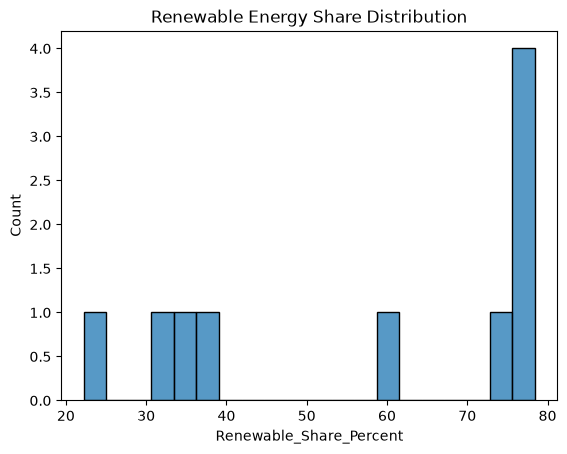

In [24]:
sns.histplot(df["Renewable_Share_Percent"], bins=20)

plt.title("Renewable Energy Share Distribution")

plt.show()

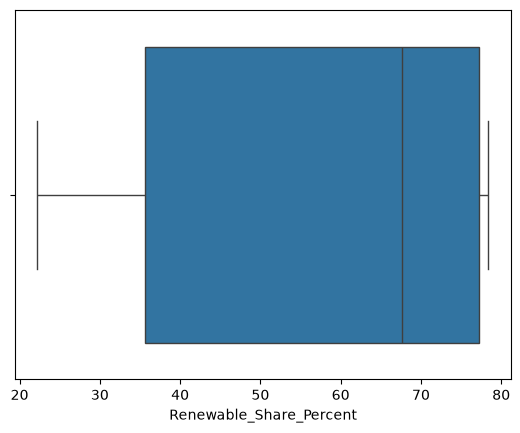

In [25]:
sns.boxplot(
    x=df["Renewable_Share_Percent"]
)

plt.show()

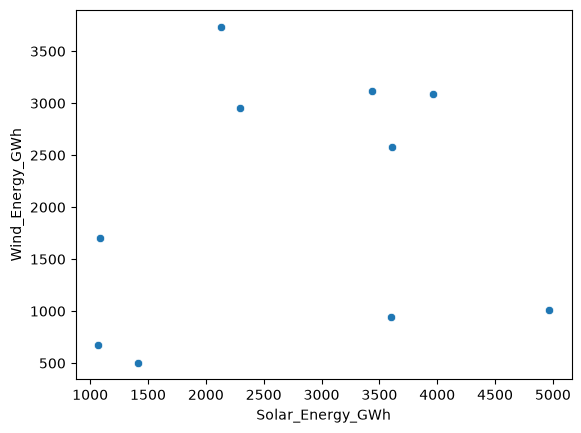

In [26]:
sns.scatterplot(
    data=df,
    x="Solar_Energy_GWh",
    y="Wind_Energy_GWh"
)

plt.show()

In [28]:
features = [
    "Solar_Energy_GWh",
    "Wind_Energy_GWh",
    "Hydro_Energy_GWh",
    "Biomass_Energy_GWh",
    "Renewable_Share_Percent",
    "GDP_Billion_USD",
    "Population_Million"
]

X = df[features]

In [29]:
X = X.fillna(X.mean())

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df[["Country", "Cluster"]].head())

   Country  Cluster
0    India        0
1  Germany        1
2      USA        1
3    China        2
4   Brazil        1


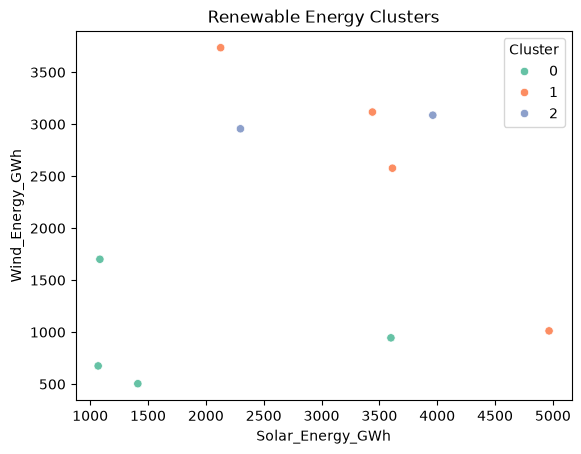

In [32]:
sns.scatterplot(
    data=df,
    x="Solar_Energy_GWh",
    y="Wind_Energy_GWh",
    hue="Cluster",
    palette="Set2"
)

plt.title("Renewable Energy Clusters")

plt.show()

Summary

 Imported the Renewable Energy dataset.

 Cleaned missing values.

 Selected important renewable energy features.

 Applied StandardScaler.

 Visualized the dataset using Seaborn.

 Applied K-Means Clustering.

 Evaluated the model using Silhouette Score.

 Successfully grouped countries with similar
 renewable energy production patterns.